# Assignment 1 Task 3

### Imports

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
from scipy.signal import butter, freqz, lfilter

### 3.2.1 Demodulation (Down conversion) and Low-pass Filtering

Loaded signal3.mat
Received passband samples: 127060
Recovered complex baseband samples: 127060
Estimated interpolation / downsampling factor: 2


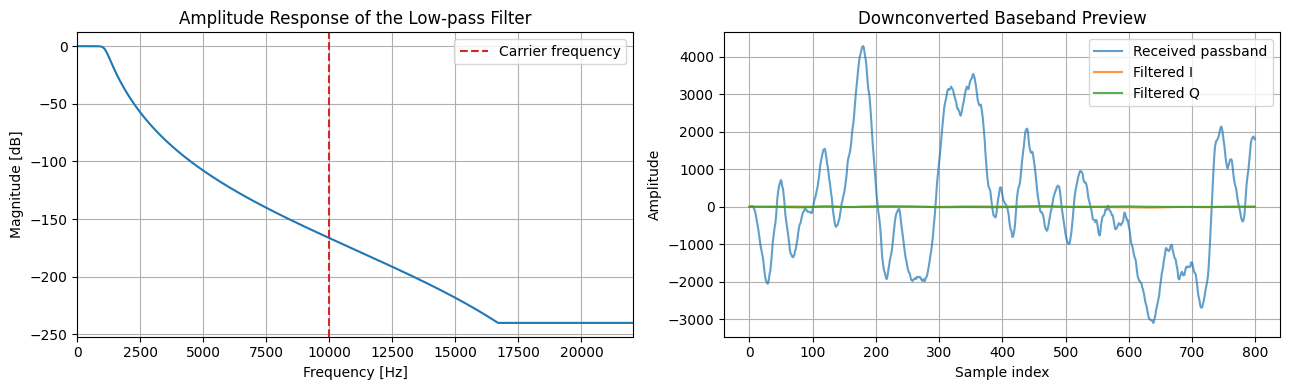

In [3]:
signal_path = Path("Signals_task3/signal3.mat")

fs = 44100
fc = 10_000
n_sc = 128
n_cp = 20
ofdm_symbol_time = 0.0058

# The transmitter interpolates the discrete-time OFDM signal before playback.
UPSAMPLING_FACTOR = int(round(fs * ofdm_symbol_time / n_sc))


def load_received_signal(path: Path) -> np.ndarray:
    data = sio.loadmat(path)
    return np.ravel(data["R"]).astype(float)


def downconvert_to_baseband(
    passband_signal: np.ndarray,
    carrier_frequency: float,
    sampling_frequency: float,
) -> tuple[np.ndarray, np.ndarray]:
    n = np.arange(passband_signal.size)
    in_phase = 2.0 * passband_signal * np.cos(2 * np.pi * carrier_frequency * n / sampling_frequency)
    quadrature = -2.0 * passband_signal * np.sin(2 * np.pi * carrier_frequency * n / sampling_frequency)
    return in_phase, quadrature


def design_lowpass_filter(order: int = 8, normalized_cutoff: float = 0.05) -> tuple[np.ndarray, np.ndarray]:
    return butter(order, normalized_cutoff)


def apply_lowpass_filter(signal: np.ndarray, b: np.ndarray, a: np.ndarray) -> np.ndarray:
    return lfilter(b, a, signal)


received_signal = load_received_signal(signal_path)
received_i, received_q = downconvert_to_baseband(received_signal, FC, FS)

b_lpf, a_lpf = design_lowpass_filter()
baseband_signal = apply_lowpass_filter(received_i, b_lpf, a_lpf) + 1j * apply_lowpass_filter(received_q, b_lpf, a_lpf)

angular_frequency, frequency_response = freqz(b_lpf, a_lpf, worN=4096)
frequency_hz = angular_frequency * FS / (2 * np.pi)

print(f"Loaded {signal_path.name}")
print(f"Received passband samples: {received_signal.size}")
print(f"Recovered complex baseband samples: {baseband_signal.size}")
print(f"Estimated interpolation / downsampling factor: {UPSAMPLING_FACTOR}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(frequency_hz, 20 * np.log10(np.maximum(np.abs(frequency_response), 1e-12)))
axes[0].axvline(FC, color="tab:red", linestyle="--", label="Carrier frequency")
axes[0].set_title("Amplitude Response of the Low-pass Filter")
axes[0].set_xlabel("Frequency [Hz]")
axes[0].set_ylabel("Magnitude [dB]")
axes[0].set_xlim(0, FS / 2)
axes[0].legend()

preview_samples = 800
axes[1].plot(received_signal[:preview_samples], label="Received passband", alpha=0.7)
axes[1].plot(np.real(baseband_signal[:preview_samples]), label="Filtered I", alpha=0.8)
axes[1].plot(np.imag(baseband_signal[:preview_samples]), label="Filtered Q", alpha=0.8)
axes[1].set_title("Downconverted Baseband Preview")
axes[1].set_xlabel("Sample index")
axes[1].set_ylabel("Amplitude")
axes[1].legend()

fig.tight_layout()
plt.show()